In [1]:
import matplotlib.pyplot as plt
import seaborn as sns  # Fixed import name
import openslide  # Use tifffile instead of openslide for regular TIFF files
from skimage import morphology
from aicspylibczi import CziFile
from tqdm import tqdm
import os
import cv2
import numpy as np
import gc
import pyvips


Image shape: (2048, 2048, 3)


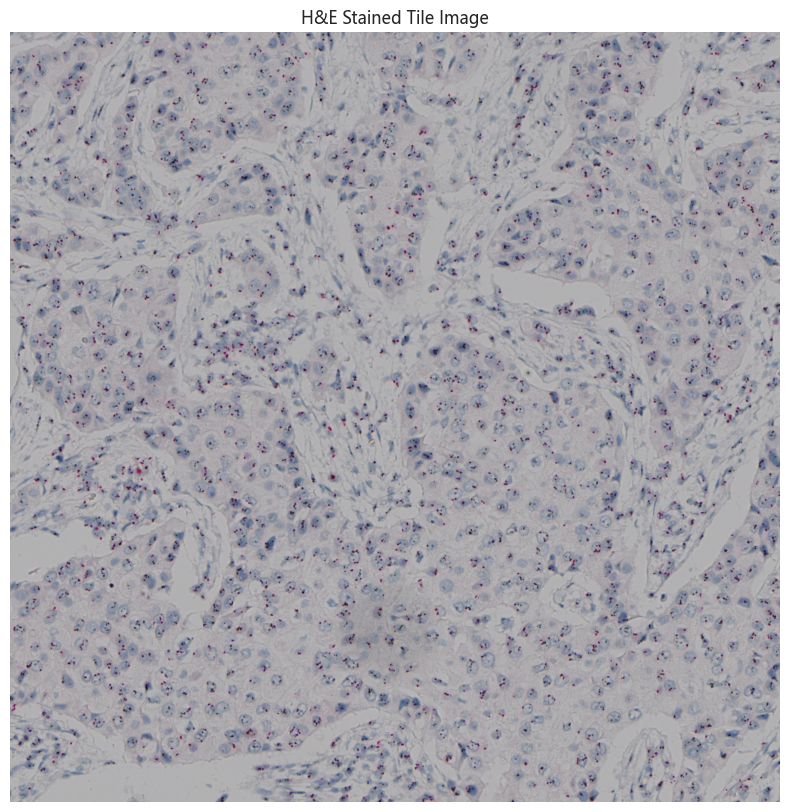

In [23]:
wsi_path = "E:\\Class\\tsgh\\picture\\WSI\\DISH_20X_ED7.tiff"

# 開啟 WSI 檔案
slide = openslide.OpenSlide(wsi_path)

# 定義要讀取的區域 (x, y, width, height)
x, y = 30000, 50000  # 起始座標
width, height = 2048, 2048  # tile 大小

# 從 level 0 讀取指定區域
tile_image = slide.read_region((x, y), 1, (width, height))

# 轉換為 RGB (OpenSlide 回傳 RGBA)
tile_image = np.array(tile_image.convert('RGB'))

print(f"Image shape: {tile_image.shape}")

# 顯示圖像
plt.figure(figsize=(10, 10))
plt.imshow(tile_image)
plt.axis('off')
plt.title('H&E Stained Tile Image')
plt.show()

# 記得關閉檔案
slide.close()

rgb_analyze

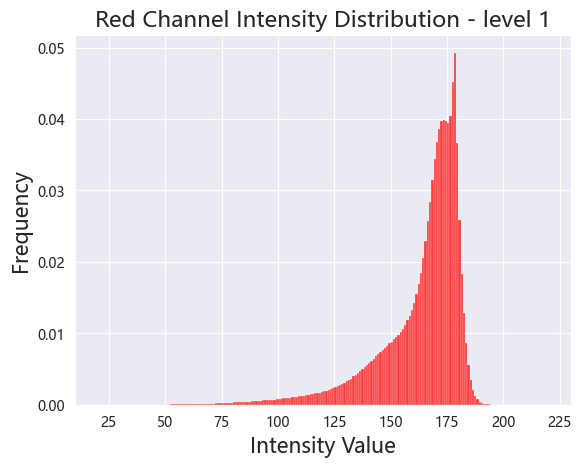

In [17]:
# Extract red channel data
if len(tile_image.shape) == 3 and tile_image.shape[2] >= 3:
    red_channel_data = tile_image[:, :, 0].flatten()
elif len(tile_image.shape) == 2:
    # Grayscale image
    red_channel_data = tile_image.flatten()
else:
    raise ValueError(f"Unexpected image shape: {tile_image.shape}")

# Add a variable for level since it's used later but not defined
level = 0

sns.histplot(red_channel_data, color="red", binwidth=1, stat="probability")
plt.xlabel('Intensity Value', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.title(f'Red Channel Intensity Distribution - level {level+1}', fontsize=16)
plt.savefig(f'red_channel_intdist_level_{level+1}.png')
plt.show()

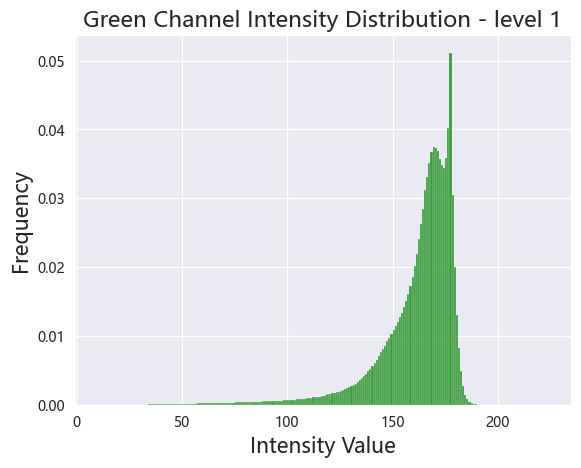

In [18]:
# Extract green channel data
if len(tile_image.shape) == 3 and tile_image.shape[2] >= 3:
    green_channel_data = tile_image[:, :, 1].flatten()
elif len(tile_image.shape) == 2:
    # Grayscale image
    green_channel_data = tile_image.flatten()
else:
    raise ValueError(f"Unexpected image shape: {tile_image.shape}")

# Add a variable for level since it's used later but not defined
level = 0

sns.histplot(green_channel_data, color="green", binwidth=1, stat="probability")
plt.xlabel('Intensity Value', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.title(f'Green Channel Intensity Distribution - level {level+1}', fontsize=16)
plt.savefig(f'green_channel_intdist_level_{level+1}.png')
plt.show()

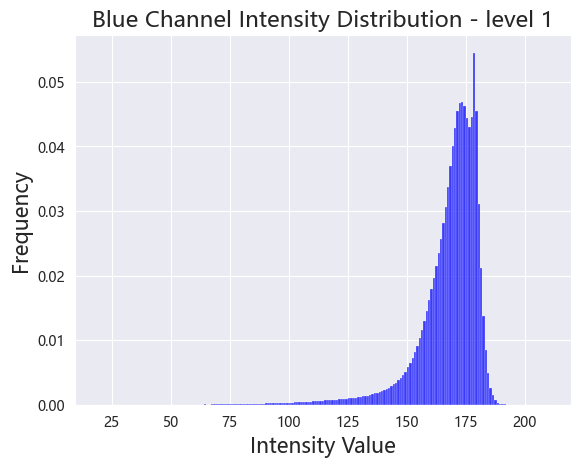

In [19]:
# Extract red channel data
if len(tile_image.shape) == 3 and tile_image.shape[2] >= 3:
    blue_channel_data = tile_image[:, :, 2].flatten()
elif len(tile_image.shape) == 2:
    # Grayscale image
    blue_channel_data = tile_image.flatten()
else:
    raise ValueError(f"Unexpected image shape: {tile_image.shape}")

# Add a variable for level since it's used later but not defined
level = 0

sns.histplot(blue_channel_data, color="blue", binwidth=1, stat="probability")
plt.xlabel('Intensity Value', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.title(f'Blue Channel Intensity Distribution - level {level+1}', fontsize=16)
plt.savefig(f'blue_channel_intdist_level_{level+1}.png')
plt.show()

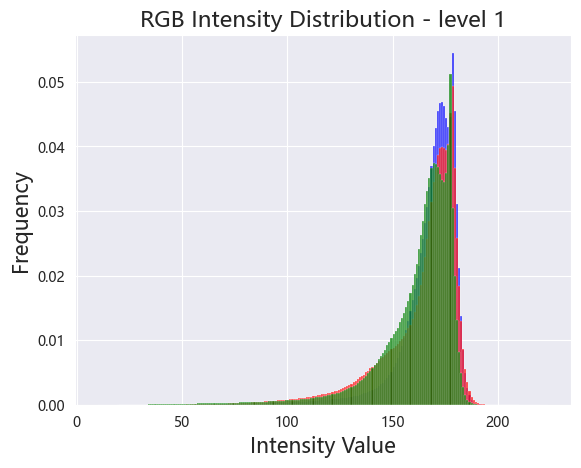

In [20]:
sns.histplot(blue_channel_data, color="blue", binwidth=1, stat="probability")
sns.histplot(red_channel_data, color="red", binwidth=1, stat="probability")
sns.histplot(green_channel_data, color="green", binwidth=1, stat="probability")
plt.xlabel('Intensity Value', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.title(f'RGB Intensity Distribution - level {level+1}', fontsize=16)
plt.savefig(f'rgb_channel_intdist_level_{level+1}.png')
plt.show()

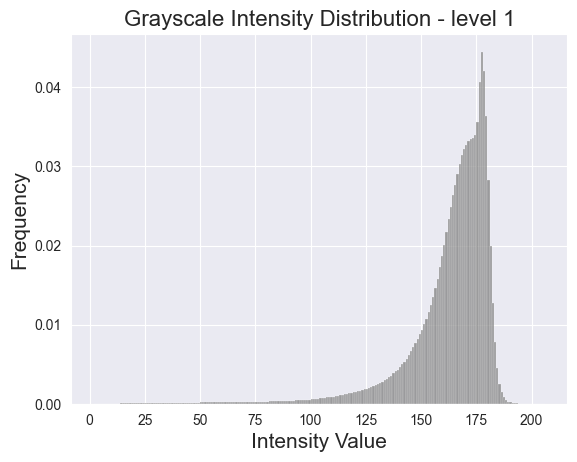

In [18]:
grayscale_data = np.array(tile_image).flatten()

sns.histplot(grayscale_data, color="gray", binwidth=1, stat="probability")
plt.xlabel('Intensity Value', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.title(f'Grayscale Intensity Distribution - level {level+1}', fontsize=16)
plt.savefig(f'grayscale_intdist_level_{level+1}.png')
plt.show()

In [24]:
def create_tissue_mask(
    rgb_image: np.ndarray,
    saturation_threshold: int = 20,
    open_kernel_size: int = 3,
    close_kernel_size: int = 5
) -> np.ndarray:
    """
    從一張 RGB 組織病理影像中，生成一個精確的二值化組織遮罩 (binary tissue mask)。
    此函式專為分離組織與淺色/白色背景而優化。

    Args:
        rgb_image (np.ndarray): 輸入的 RGB 影像 (HxWx3)。
        saturation_threshold (int): HSV 色彩空間中飽和度(S)的閾值。
                                   低於此值的像素被視為背景。
        open_kernel_size (int): 形態學開運算的核心大小，用於移除小的噪點。
        close_kernel_size (int): 形態學閉運算的核心大小，用於填補組織內部的小空洞。

    Returns:
        np.ndarray: 一個二值化的 uint8 遮罩 (HxW)，組織區域為 255，背景為 0。
    """
    # 步驟 1: 確保輸入是 3 通道的 RGB 影像
    if rgb_image.ndim != 3 or rgb_image.shape[2] != 3:
        # 如果是 RGBA 影像，則移除 Alpha 通道
        if rgb_image.shape[2] == 4:
            rgb_image = rgb_image[:, :, :3]
        else:
            raise ValueError("輸入必須是 3 通道的 RGB 影像")

    # 步驟 2: 將影像從 RGB 轉換為 HSV 色彩空間
    # HSV 能更好地分離顏色強度(V)與色彩飽和度(S)，後者對區分背景非常有效
    hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2HSV)

    # 步驟 3: 提取飽和度(S)通道
    s_channel = hsv_image[:, :, 1]

    # 步驟 4: 根據飽和度閾值進行二值化，產生初始遮罩
    _, binary_mask = cv2.threshold(s_channel, saturation_threshold, 255, cv2.THRESH_BINARY)

    # 步驟 5: 進行形態學清洗，以優化遮罩品質
    # 開運算 (Opening): 先侵蝕後膨脹，可以有效移除孤立的小噪點
    open_kernel = morphology.disk(open_kernel_size)
    cleaned_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, open_kernel)

    # 閉運算 (Closing): 先膨脹後侵蝕，可以填補組織內部的小空洞
    close_kernel = morphology.disk(close_kernel_size)
    final_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_CLOSE, close_kernel)

    return final_mask

In [25]:
# 設置中文字體支援
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


影像處理完成，顯示比較結果：


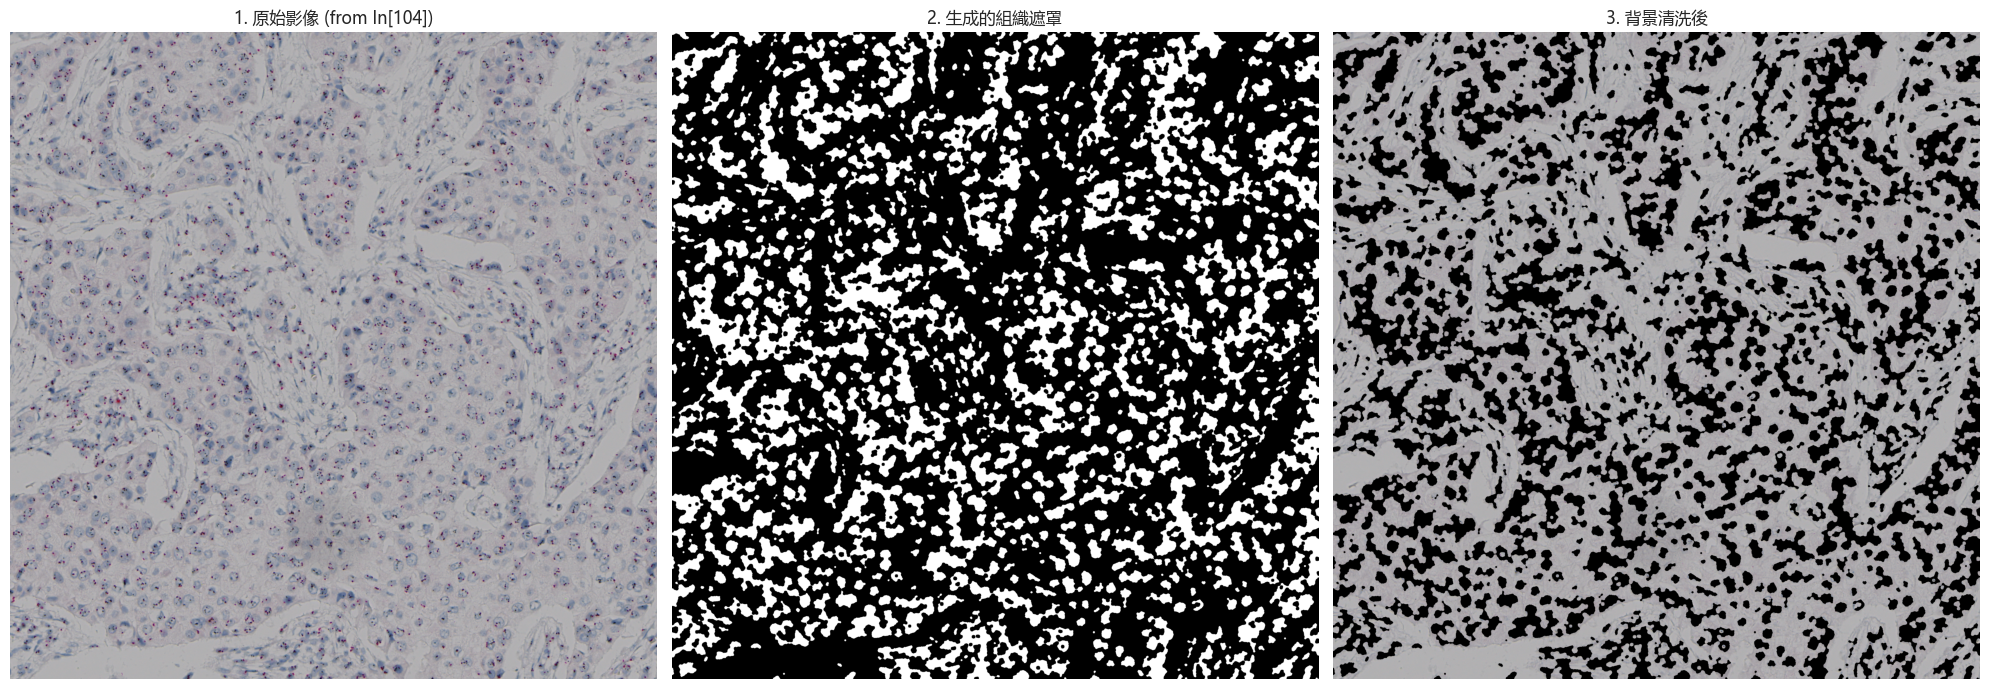

In [30]:
# --- 執行背景清洗 ---
# 我們將對上面讀取的 `tile_image` 進行操作
# 您可以調整 saturation_threshold 來改變清洗的靈敏度
tissue_mask = create_tissue_mask(tile_image, saturation_threshold=10)

# --- 建立反向遮罩 ---
# 使用 cv2.bitwise_not 來反轉遮罩，將組織區域變為黑色，背景變為白色
inverted_mask = cv2.bitwise_not(tissue_mask)

# --- 將反向遮罩應用回原始影像 ---
# 這裡我們使用 cv2.bitwise_and，只保留反向遮罩區域內的原始像素 (即背景)
cleaned_image = cv2.bitwise_and(tile_image, tile_image, mask=inverted_mask)

# --- 視覺化比較結果 ---
print("影像處理完成，顯示比較結果：")
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(tile_image)
axes[0].set_title('1. 原始影像 (from In[104])')
axes[0].axis('off')

axes[1].imshow(tissue_mask, cmap='gray')
axes[1].set_title('2. 生成的組織遮罩')
axes[1].axis('off')

axes[2].imshow(cleaned_image)
axes[2].set_title('3. 背景清洗後')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [22]:
# --- 參數設定 ---
CZI_FILE_PATH = "E:/Class/tsgh/picture/whole_size/DISH_20X_ED7.czi"
OUTPUT_TIFF_PATH = "DISH_final_stitched_white_bg.tiff" # 直接輸出最終結果
BATCH_SIZE = 100
SCALE_FACTOR = 0.25 # 您可以按需調整

In [18]:
# --- 步驟 1: 讀取 CZI 座標元數據 ---
print(f"正在從 {os.path.basename(CZI_FILE_PATH)} 讀取座標元數據...")
czi = CziFile(CZI_FILE_PATH)
all_tiles_bboxes_items = list(czi.get_all_mosaic_tile_bounding_boxes().items())
total_tiles = len(all_tiles_bboxes_items)

# --- 步驟 2: 計算縮放後的畫布尺寸 ---
print(f"正在計算縮放因子為 {SCALE_FACTOR} 的最終畫布尺寸...")
all_bboxes = [item[1] for item in all_tiles_bboxes_items]
min_x = min(bbox.x for bbox in all_bboxes)
min_y = min(bbox.y for bbox in all_bboxes)
max_x = max(bbox.x + bbox.w for bbox in all_bboxes)
max_y = max(bbox.y + bbox.h for bbox in all_bboxes)

正在從 DISH_20X_ED7.czi 讀取座標元數據...
正在計算縮放因子為 0.25 的最終畫布尺寸...


In [19]:
canvas_width = int((max_x - min_x) * SCALE_FACTOR)
canvas_height = int((max_y - min_y) * SCALE_FACTOR)
print(f"縮放後畫布尺寸為: {canvas_width} x {canvas_height} 像素。")

# --- 步驟 3: 創建白色背景的畫布 ---
# 創建一個全白的畫布
# np.full 會用指定值 (255) 填充整個陣列
final_canvas = np.full((canvas_height, canvas_width, 3), 255, dtype=np.uint8)
print("白色背景畫布已創建。")

縮放後畫布尺寸為: 40314 x 30544 像素。
白色背景畫布已創建。


In [20]:
# --- 步驟 4: 分批次處理並拼接 ---
print(f"開始以每批 {BATCH_SIZE} 個圖塊的方式進行處理...")
num_batches = (total_tiles + BATCH_SIZE - 1) // BATCH_SIZE
for i in tqdm(range(num_batches), desc="處理批次"):
    batch_start = i * BATCH_SIZE
    batch_end = min((i + 1) * BATCH_SIZE, total_tiles)
    current_batch_items = all_tiles_bboxes_items[batch_start:batch_end]
    current_batch_bboxes = [item[1] for item in current_batch_items]

    batch_min_x = min(bbox.x for bbox in current_batch_bboxes)
    batch_min_y = min(bbox.y for bbox in current_batch_bboxes)
    batch_max_x = max(bbox.x + bbox.w for bbox in current_batch_bboxes)
    batch_max_y = max(bbox.y + bbox.h for bbox in current_batch_bboxes)

    batch_region_coords = (batch_min_x, batch_min_y, max(0, batch_max_x - batch_min_x), max(0, batch_max_y - batch_min_y))

    try:
        batch_image_bgr = czi.read_mosaic(batch_region_coords, scale_factor=SCALE_FACTOR, C=0)
        if batch_image_bgr is None or batch_image_bgr.size == 0:
            continue

        batch_image_bgr = np.squeeze(batch_image_bgr)
        batch_image_rgb = cv2.cvtColor(batch_image_bgr, cv2.COLOR_BGR2RGB)

        batch_mask = create_tissue_mask(batch_image_rgb, saturation_threshold=20)

        for tile_info, bbox in current_batch_items:
            relative_x = int((bbox.x - batch_min_x) * SCALE_FACTOR)
            relative_y = int((bbox.y - batch_min_y) * SCALE_FACTOR)
            scaled_h = int(bbox.h * SCALE_FACTOR)
            scaled_w = int(bbox.w * SCALE_FACTOR)

            end_y = min(relative_y + scaled_h, batch_image_bgr.shape[0])
            end_x = min(relative_x + scaled_w, batch_image_bgr.shape[1])

            # 從原始批次大圖中裁切出對應的圖塊
            original_tile = batch_image_bgr[relative_y:end_y, relative_x:end_x]
            # 從批次遮罩中裁切出對應的遮罩
            tile_mask = batch_mask[relative_y:end_y, relative_x:end_x]

            canvas_x = int((bbox.x - min_x) * SCALE_FACTOR)
            canvas_y = int((bbox.y - min_y) * SCALE_FACTOR)

            h, w, _ = original_tile.shape

            # 關鍵修改: 使用遮罩進行條件性貼上
            # 只將遮罩中為白色的區域 (組織區域) 貼到畫布上
            # 由於畫布底色已是白色，這完美達成了「黑背景變白」的效果
            # 確保 tile_mask 是 3 通道
            tile_mask_3d = cv2.cvtColor(tile_mask, cv2.COLOR_GRAY2BGR)
            # 找到畫布上要貼上的區域
            canvas_roi = final_canvas[canvas_y:canvas_y+h, canvas_x:canvas_x+w]
            # 使用 np.where 進行條件賦值
            final_canvas[canvas_y:canvas_y+h, canvas_x:canvas_x+w] = np.where(tile_mask_3d > 0, original_tile, canvas_roi)

    except Exception as e:
        print(f"處理批次 {i+1} 時發生錯誤: {e}")
    finally:
        # 釋放資源
        if 'batch_image_bgr' in locals(): del batch_image_bgr
        if 'batch_image_rgb' in locals(): del batch_image_rgb
        if 'batch_mask' in locals(): del batch_mask
        gc.collect()

print("所有批次處理並拼接完成！")



開始以每批 100 個圖塊的方式進行處理...



處理批次:   0%|          | 0/48 [00:00<?, ?it/s]Exception ignored in: <function tqdm.__del__ at 0x00000250ABCB68C0>
Traceback (most recent call last):
  File "E:\Class\tsgh\.venv\lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "E:\Class\tsgh\.venv\lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'

處理批次: 100%|██████████| 48/48 [03:54<00:00,  4.88s/it]

所有批次處理並拼接完成！


In [21]:
# --- 步驟 5: 使用 PyVips 儲存最終的白色背景畫布 ---
print(f"正在使用 pyvips 儲存最終結果至 {OUTPUT_TIFF_PATH}...")
try:
    height, width, bands = final_canvas.shape
    linear = final_canvas.reshape(width * height * bands)
    vips_image = pyvips.Image.new_from_memory(linear.data, width, height, bands, 'uchar')

    vips_image.tiffsave(
        OUTPUT_TIFF_PATH,
        tile=True,
        pyramid=True,
        compression='jpeg',
        bigtiff=True
    )
    print("儲存成功！")

except Exception as e:
    print(f"使用 pyvips 儲存時發生錯誤: {e}")
finally:
    del final_canvas
    del czi
    gc.collect()

正在使用 pyvips 儲存最終結果至 DISH_final_stitched_white_bg.tiff...
儲存成功！
